# Building Neural Networks

## Goal

Build a neural network from scratch to understand how neural networks learn from data, update their parameters, and make predictions.

The project starts from the simplest possible model and evolves step by step toward multiclass classification, hidden layers, mini-batch training, and deeper networks.

---

## Version 3

Extend the multiclass linear model by adding one hidden layer.

The model will:

- use all 10 Fashion-MNIST classes
- keep the 784 input pixels
- add a hidden layer with 64 neurons
- introduce the ReLU activation function
- keep 10 output neurons with softmax
- use multiclass cross-entropy loss
- train both layers with backpropagation and gradient descent
- predict the class with the highest probability
- evaluate accuracy on the full Fashion-MNIST test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/"

train = pd.read_csv(PATH + "fashion-mnist_train.csv")
test  = pd.read_csv(PATH + "fashion-mnist_test.csv")

In [3]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [5]:
# Separate pixels from labels

X = train.drop(columns="label").values
y = train["label"].values

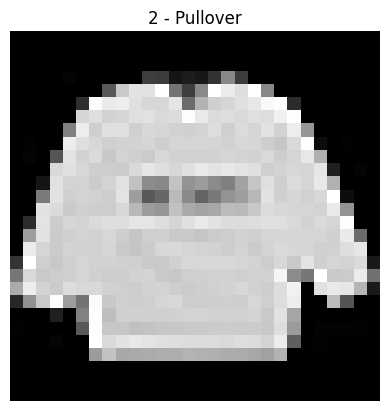

In [6]:
plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"{y[0]} - {labels[y[0]]}")
plt.axis("off")
plt.show()

In [7]:
# Normalize pixel values from 0-255 to 0-1

X = X / 255.0

y_onehot = np.eye(10)[y]

## Building the model

We now build a multiclass neural network with one hidden layer.

### Softmax activation

The softmax function converts the output scores into class probabilities that sum to `1`.

In [8]:
# Convert raw output scores into class probabilities

def softmax(z):
    exp = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [9]:
# Keep positive values and set negative values to zero

def relu(z):
    return np.maximum(0, z)

In [10]:
def train(X, y, w1, b1, w2, b2, lr=0.1, epochs=200):
    for _ in range(epochs):
        z1 = X @ w1 + b1
        a1 = relu(z1)

        z2 = a1 @ w2 + b2
        pred = softmax(z2)

        loss = -np.mean(np.sum(y * np.log(pred), axis=1))

        dz2 = pred - y
        dw2 = a1.T @ dz2 / len(y)
        db2 = np.mean(dz2, axis=0)

        da1 = dz2 @ w2.T
        dz1 = da1 * (z1 > 0)

        dw1 = X.T @ dz1 / len(y)
        db1 = np.mean(dz1, axis=0)

        w1 -= lr * dw1
        b1 -= lr * db1
        w2 -= lr * dw2
        b2 -= lr * db2

    return w1, b1, w2, b2, loss

In [11]:
# Initialize two layers

np.random.seed(42)

w1 = np.random.randn(X.shape[1], 64) * np.sqrt(2 / X.shape[1])
b1 = np.zeros(64)

w2 = np.random.randn(64, 10) * np.sqrt(2 / 64)
b2 = np.zeros(10)

### Training

The model repeatedly measures its prediction error and updates all weights and biases to reduce the loss.

In [12]:
w1, b1, w2, b2, loss = train(X, y_onehot, w1, b1, w2, b2)

print(f"Train loss: {loss:.4f}")

Train loss: 0.5895


## Evaluation

The model predicts the class with the highest probability.

In [13]:
z1 = X @ w1 + b1
a1 = relu(z1)

z2 = a1 @ w2 + b2
pred = softmax(z2)

y_pred = np.argmax(pred, axis=1)
accuracy = np.mean(y_pred == y)

print(f"Train accuracy: {accuracy:.2%}")

Train accuracy: 79.03%


In [14]:
X_test = test.drop(columns="label").values / 255.0
y_test = test["label"].values

z1 = X_test @ w1 + b1
a1 = relu(z1)

z2 = a1 @ w2 + b2
pred = softmax(z2)

preds = np.argmax(pred, axis=1)

accuracy = np.mean(preds == y_test)

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 79.02%


## Notes

This third version extends the multiclass model by adding one hidden layer.

- All 10 Fashion-MNIST classes are used.
- Images are flattened into 784 pixel values and normalized to `0-1`.
- The model uses a hidden layer with 64 neurons.
- ReLU introduces non-linearity in the hidden layer.
- The output layer uses 10 neurons, one for each class.
- Softmax converts the output scores into class probabilities.
- Multiclass cross-entropy measures the error.
- Backpropagation computes the gradients through both layers.
- Gradient descent updates all weights and biases.
- Final predictions use the class with the highest probability.
- The model is evaluated on the full Fashion-MNIST training and test sets.
- Random initialization uses a fixed seed for reproducible results.
- Training runs for a fixed number of epochs to keep execution predictable and results reproducible.

Future versions will introduce new components and gradually evolve the architecture.